# Импорты

In [1]:
!pip install pandas numpy matplotlib statsmodels prophet neuralprophet mlflow scikit-learn optuna optuna-integration[mlflow] catboost lightgbm pmdarima prophet neuralprophet

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
try:
    import phik
except ImportError:
    !pip install phik
    import phik
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from neuralprophet import NeuralProphet, set_log_level, save
import mlflow
from sklearn.metrics import mean_absolute_error, mean_squared_error
try:
    !pip install lightgbm
    from lightgbm import LGBMRegressor
except:
    from lightgbm import LGBMRegressor
try:
    from catboost import CatBoostRegressor
    from catboost import Pool
except:
    !pip install catboost
    from catboost import CatBoostRegressor
    from catboost import Pool
from sklearn.model_selection import TimeSeriesSplit
try:
    import optuna
    from optuna.integration.mlflow import MLflowCallback
except:
    !pip install optuna
    import optuna
    from optuna.integration.mlflow import MLflowCallback
import os

In [3]:
sns.set(rc={'figure.figsize':(15, 6)})

In [4]:
try:
    data = pd.read_csv('taxi.csv', parse_dates = ['datetime'], index_col = ['datetime'])
except:
    data = pd.read_csv('data/taxi.csv', parse_dates = ['datetime'], index_col = ['datetime'])

In [5]:
data.sort_index(inplace=True)
data.head(5)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [6]:
display(data.describe(), data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


None

In [7]:
data.isna().sum()

num_orders    0
dtype: int64

In [8]:
data = data.resample('1H').sum()
data.dropna(inplace=True)
data.head(5)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


# Analys

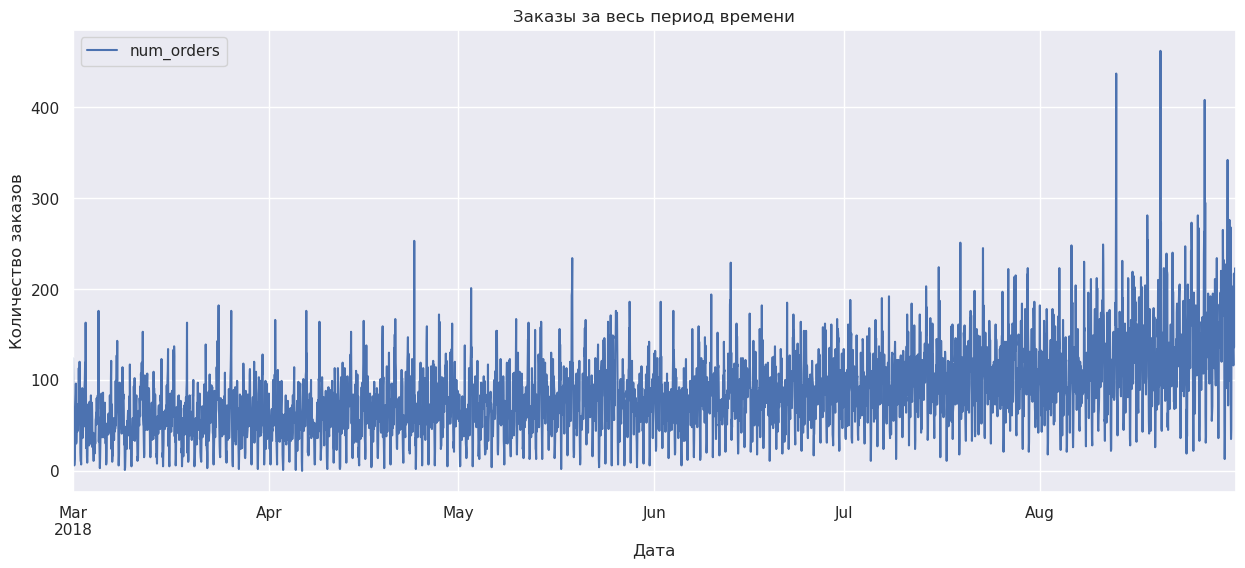

Среднее значение до Июня: 65.18055555555556
Среднее значение после Июня: 103.84239130434783


In [9]:
data.plot()
plt.title('Заказы за весь период времени')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.show()

print(f'Среднее значение до Июня: {data[: "2018-06-01"]["num_orders"].mean()}')
print(f'Среднее значение после Июня: {data["2018-06-01":]["num_orders"].mean()}')

In [10]:
split_date = '2018-06-01'
mean_before = data[:split_date]['num_orders'].mean()
mean_after = data[split_date:]['num_orders'].mean()
print(f'Среднее до {split_date}: {mean_before:.2f}')
print(f'Среднее после {split_date}: {mean_after:.2f}')
print(f'Разница: {abs(mean_before - mean_after):.2f} ({abs(mean_before - mean_after)/mean_before*100:.1f}%)')

Среднее до 2018-06-01: 65.18
Среднее после 2018-06-01: 103.84
Разница: 38.66 (59.3%)


In [11]:
def adf_test(series, alpha=0.05):
    result = adfuller(series.dropna(), autolag='AIC')
    adf_stat = result[0]
    p_value = result[1]
    crit_values = result[4]
    
    print(f'ADF Statistic: {adf_stat:.4f}')
    print(f'p-value: {p_value:.4f}')
    print('Критические значения:')
    for key, value in crit_values.items():
        print(f'   {key}: {value:.4f}')
    
    print(f"\nГипотезы:")
    print(f"H0: Ряд нестационарен (есть единичный корень)")
    print(f"H1: Ряд стационарен")
    
    if p_value < alpha:
        print(f"→ Отвергаем H0 на уровне значимости {alpha*100}%: ряд СТАЦИОНАРЕН")
    else:
        print(f"→ Не отвергаем H0: ряд НЕСТАЦИОНАРЕН")
    
    return result

adf_result = adf_test(data['num_orders'], alpha=0.01)

ADF Statistic: -3.0689
p-value: 0.0289
Критические значения:
   1%: -3.4318
   5%: -2.8622
   10%: -2.5671

Гипотезы:
H0: Ряд нестационарен (есть единичный корень)
H1: Ряд стационарен
→ Не отвергаем H0: ряд НЕСТАЦИОНАРЕН


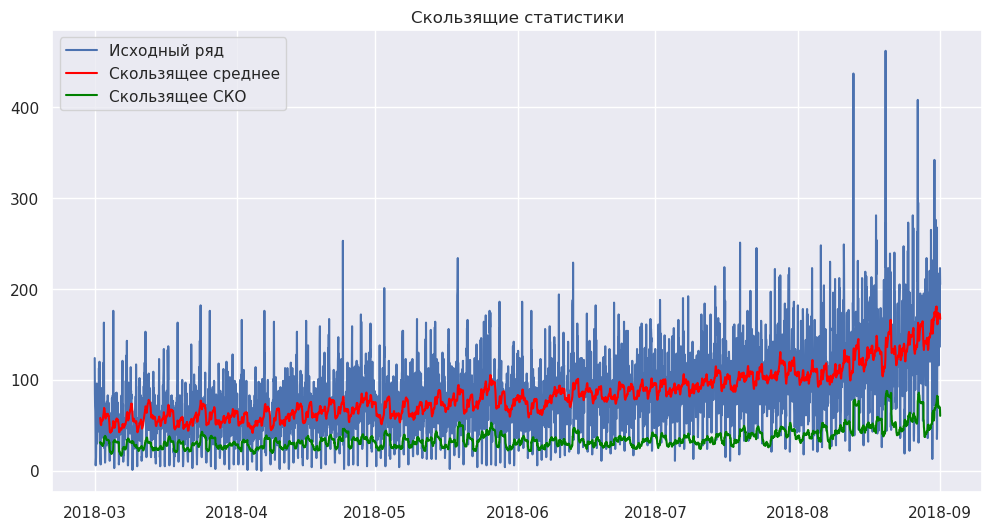

In [12]:
window = 30
data_tmp = data.copy()
data_tmp['rolling_mean'] = data['num_orders'].rolling(window).mean()
data_tmp['rolling_std'] = data['num_orders'].rolling(window).std()

plt.figure(figsize=(12, 6))
plt.plot(data_tmp['num_orders'], label='Исходный ряд')
plt.plot(data_tmp['rolling_mean'], label='Скользящее среднее', color='red')
plt.plot(data_tmp['rolling_std'], label='Скользящее СКО', color='green')
plt.legend()
plt.title('Скользящие статистики')
plt.show()

In [13]:
data

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
...,...
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159


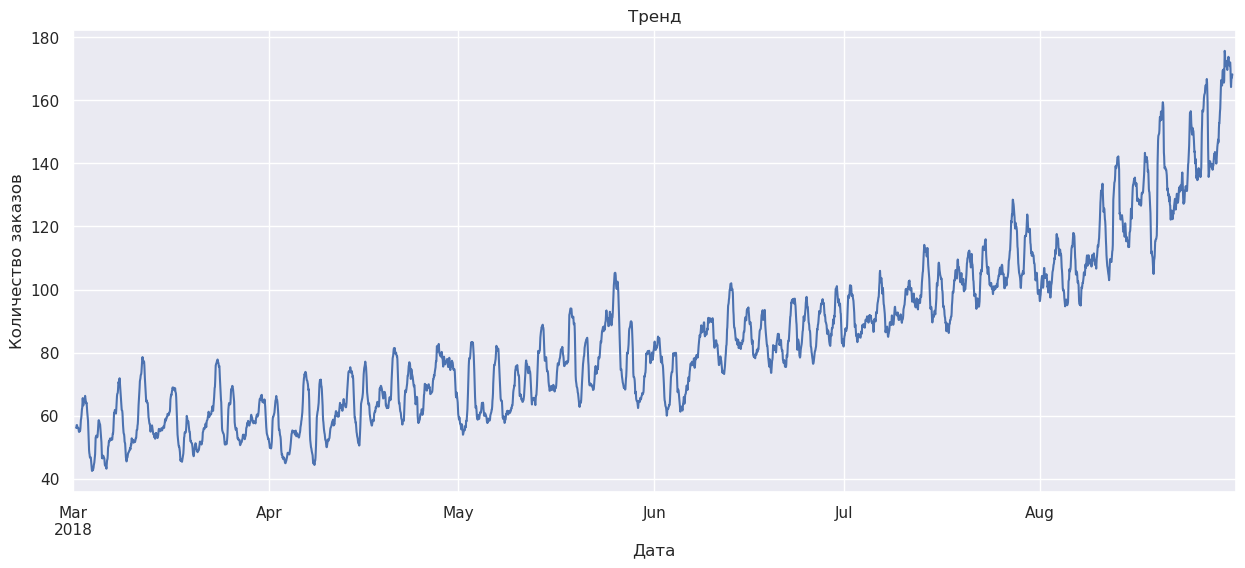

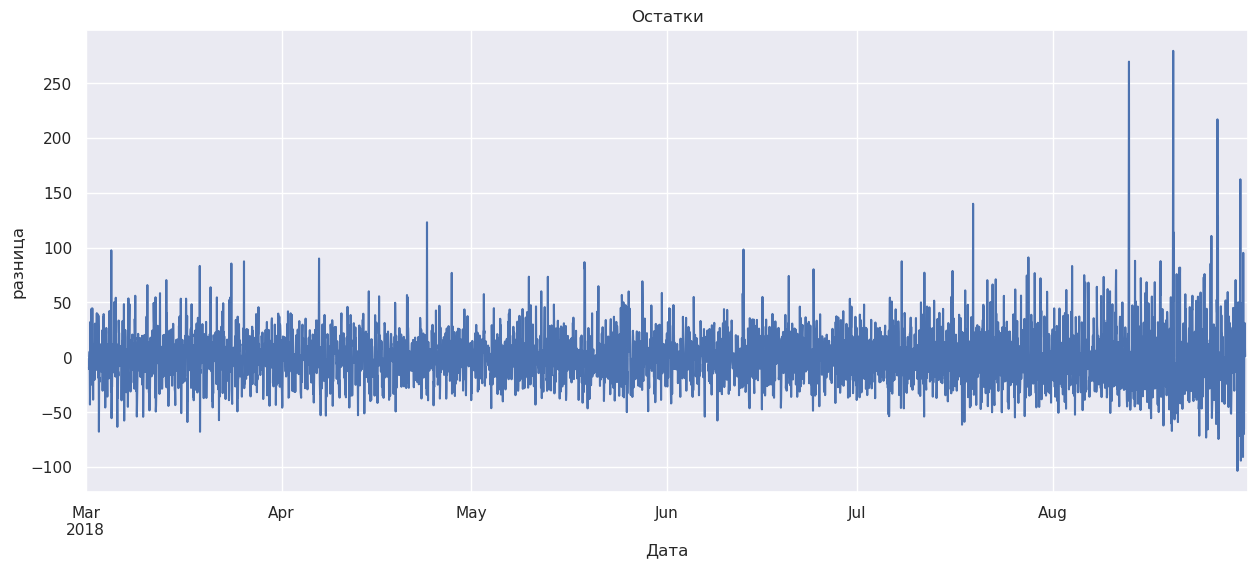

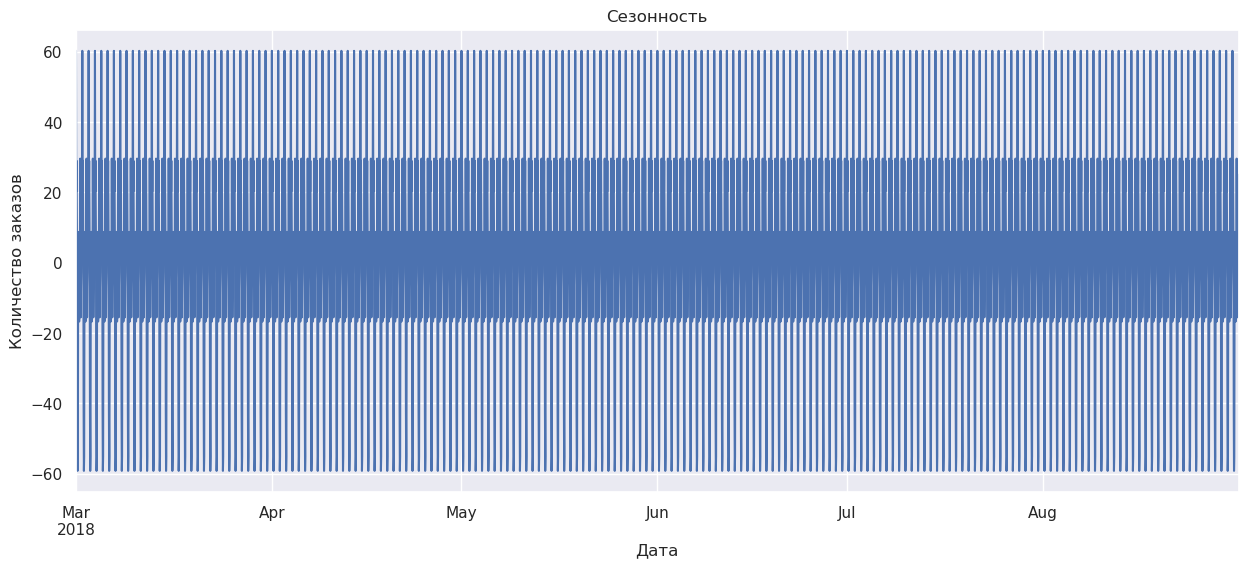

In [14]:
decomposition = seasonal_decompose(data)
decomposition.trend.plot(ax = plt.gca())
plt.title('Тренд')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.show()

decomposition.resid.plot(ax = plt.gca())
plt.title('Остатки')
plt.xlabel('Дата')
plt.ylabel('разница')
plt.show()

decomposition.seasonal.plot(ax = plt.gca())
plt.title('Сезонность')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.show()

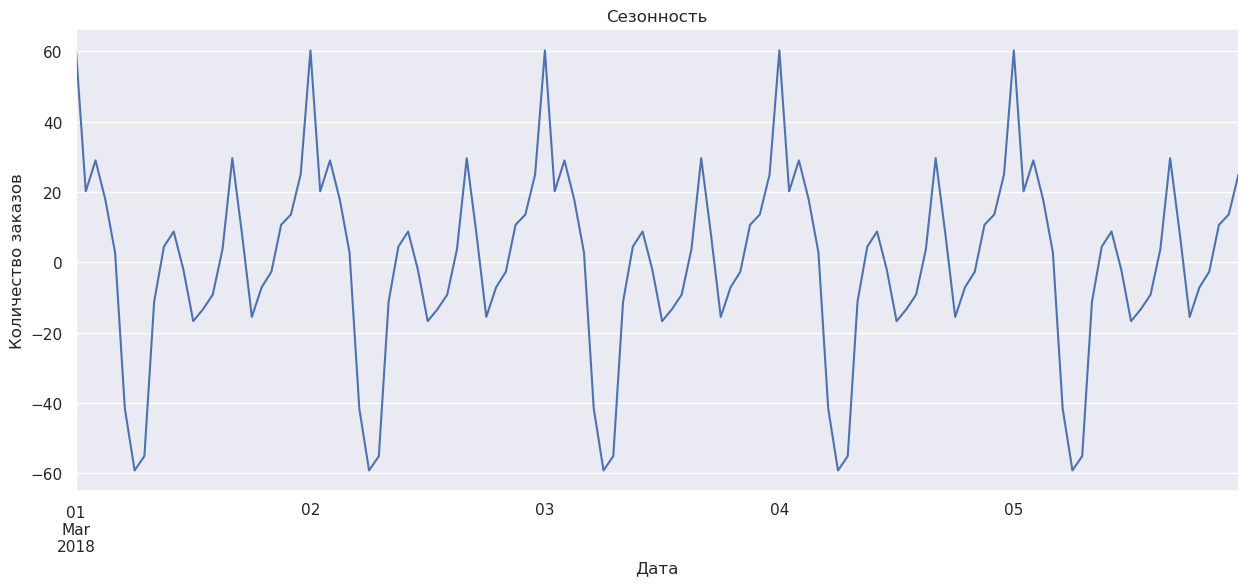

In [15]:
decomposition.seasonal['2018-03-01':'2018-03-05'].plot(ax = plt.gca())
plt.title('Сезонность')
plt.xlabel('Дата')
plt.ylabel('Количество заказов');

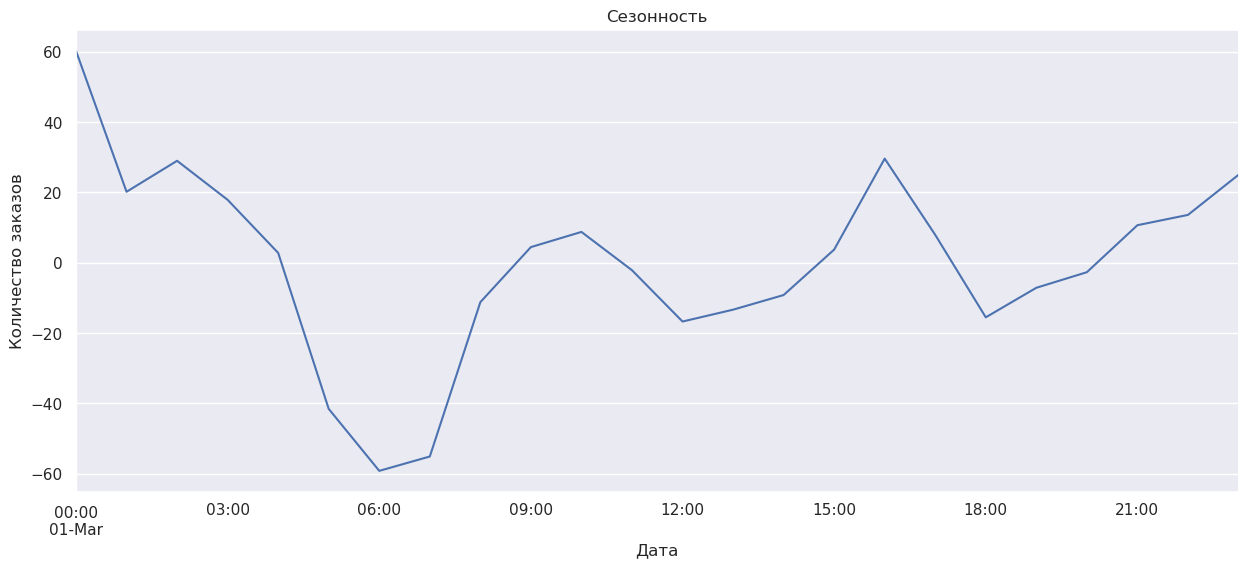

In [16]:
decomposition.seasonal['2018-03-01'].plot(ax = plt.gca())
plt.title('Сезонность')
plt.xlabel('Дата')
plt.ylabel('Количество заказов');

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_221/1418391828.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_aug['rolling_mean'] = data_aug.shift().rolling(5).mean()



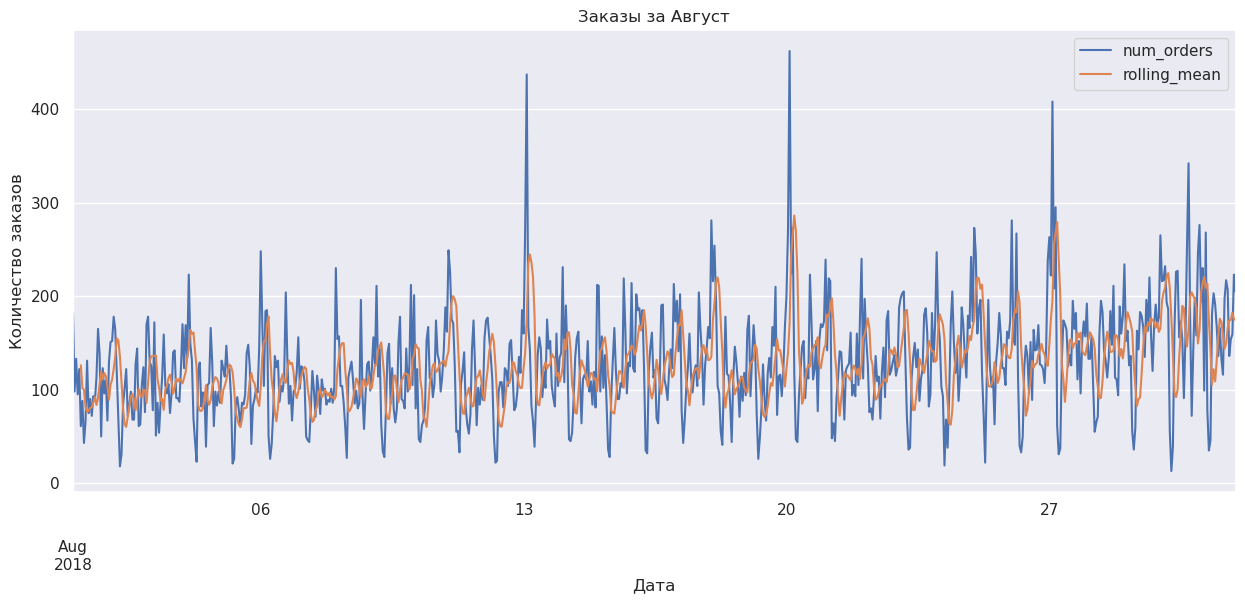

In [17]:
data_aug = data['2018-08-01':]
data_aug['rolling_mean'] = data_aug.shift().rolling(5).mean()
data_aug.plot()
plt.title('Заказы за Август');
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.show()

In [18]:
data['diff'] = data['num_orders'].diff().dropna()

data['log'] = np.log(data['num_orders'])
data['log_diff'] = data['log'].diff().dropna()

adf_test(data['diff'])

WARNING - (py.warnings._showwarnmsg) - /opt/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)



ADF Statistic: -15.7932
p-value: 0.0000
Критические значения:
   1%: -3.4318
   5%: -2.8622
   10%: -2.5671

Гипотезы:
H0: Ряд нестационарен (есть единичный корень)
H1: Ряд стационарен
→ Отвергаем H0 на уровне значимости 5.0%: ряд СТАЦИОНАРЕН


(-15.79323425741061,
 1.0958776746507192e-28,
 31,
 4383,
 {'1%': -3.431842843698785,
  '5%': -2.8621996550511697,
  '10%': -2.56712113869159},
 41720.139669637894)

In [19]:
def create_features(df, target, lags=12):
    df = df.copy()
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target].shift(lag)
    df['rolling_mean'] = df[target].rolling(7).mean()
    df['rolling_std'] = df[target].rolling(7).std()
    return df.dropna()


In [20]:
df_sarima = data[['num_orders']].copy()

df_ml = create_features(data, 'diff', lags=12)
df_ml.head()

,num_orders,diff,log,log_diff,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean,rolling_std
datetime,,,,,,,,,,,,,,,,,,
2018-03-01 13:00:00,32,2.0,3.465736,0.064539,-66.0,32.0,-5.0,35.0,19.0,3.0,6.0,-37.0,-23.0,-5.0,-14.0,-39.0,2.857143,34.026600
2018-03-01 14:00:00,48,16.0,3.871201,0.405465,2.0,-66.0,32.0,-5.0,35.0,19.0,3.0,6.0,-37.0,-23.0,-5.0,-14.0,4.714286,34.388536
2018-03-01 15:00:00,66,18.0,4.189655,0.318454,16.0,2.0,-66.0,32.0,-5.0,35.0,19.0,3.0,6.0,-37.0,-23.0,-5.0,4.571429,34.321311
2018-03-01 16:00:00,43,-23.0,3.761200,-0.428455,18.0,16.0,2.0,-66.0,32.0,-5.0,35.0,19.0,3.0,6.0,-37.0,-23.0,-3.714286,32.714494
2018-03-01 17:00:00,44,1.0,3.784190,0.022990,-23.0,18.0,16.0,2.0,-66.0,32.0,-5.0,35.0,19.0,3.0,6.0,-37.0,-2.857143,32.753771


In [21]:
X = df_ml.drop(columns=['diff'])
y = df_ml['diff']

In [22]:
mlflow.set_experiment("Taxi")

<Experiment: artifact_location='s3://mlops-check/mlflow/908615356403912986', creation_time=1744309304097, experiment_id='908615356403912986', last_update_time=1744309304097, lifecycle_stage='active', name='Taxi', tags={}>

In [23]:
def optimize_catboost(X, y):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 500),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        }
        
        tscv = TimeSeriesSplit(n_splits=3)
        scores = []
        
        for train_idx, val_idx in tscv.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            model = CatBoostRegressor(**params, verbose=0)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
            scores.append(mean_absolute_error(y_val, preds))
        
        return np.mean(scores)

    mlflow_callback = MLflowCallback(
        tracking_uri=mlflow.get_tracking_uri(),
        metric_name='MAE'
    )
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20, callbacks=[mlflow_callback])
    
    return study.best_params, study.best_value

best_params, best_mae = optimize_catboost(X, y)

with mlflow.start_run(run_name="CatBoost_Optuna_Best", experiment_id = 908615356403912986):
    mlflow.log_params(best_params)
    mlflow.log_metric("MAE", best_mae)
    best_model = CatBoostRegressor(**best_params, verbose=0)
    best_model.fit(X, y)
    mlflow.catboost.log_model(best_model, "catboost_optuna_model")

WARNING - (py.warnings._showwarnmsg) - /tmp/ipykernel_221/849340835.py:24: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflow_callback = MLflowCallback(

[I 2025-04-10 20:40:51,357] A new study created in memory with name: no-name-8ada1e30-6776-40c6-85f8-ceb67e070aee
[I 2025-04-10 20:40:54,425] Trial 0 finished with value: 4.214672505438171 and parameters: {'iterations': 369, 'depth': 9, 'learning_rate': 0.1737594292984414, 'l2_leaf_reg': 5.536928470511889}. Best is trial 0 with value: 4.214672505438171.
2025/04/10 20:40:54 INFO mlflow.tracking.fluent: Experiment with name 'no-name-8ada1e30-6776-40c6-85f8-ceb67e070aee' does not exist. Creating a new experiment.
2025/04/10 20:40:54 INFO mlflow.tracking._tracking_service.client: 🏃 View run 0 at: http://mlflow-service:5000/#/experiments/887234918541742625/runs/892ad27e0b99473ebc75c7ee04610210.
2025/04/10 20:40:54 INFO mlflow.tracking._tracking_service.client: 🧪 Vie

In [24]:
train_size = int(len(df_sarima) * 0.8)
train, test = df_sarima.iloc[:train_size], df_sarima.iloc[train_size:]

In [25]:
with mlflow.start_run(run_name="SARIMA", experiment_id = 908615356403912986):
    order = (1, 1, 1)
    seasonal_order = (1, 1, 1, 12)
    
    model_sarima = SARIMAX(train['num_orders'], 
                         order=order, 
                         seasonal_order=seasonal_order)
    results_sarima = model_sarima.fit(disp=False)
    
    forecast = results_sarima.get_forecast(steps=len(test))
    preds = forecast.predicted_mean
    
    mae = mean_absolute_error(test['num_orders'], preds)
    rmse = np.sqrt(mean_squared_error(test['num_orders'], preds))
    
    mlflow.log_params({
        'order': order,
        'seasonal_order': seasonal_order
    })
    mlflow.log_metrics({
        'MAE': mae,
        'RMSE': rmse
    })
    mlflow.statsmodels.log_model(results_sarima, "sarima_model")
    
    print(f"SARIMA - MAE: {mae:.2f}, RMSE: {rmse:.2f}")

2025/04/10 20:41:52 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.
2025/04/10 20:41:52 INFO mlflow.tracking._tracking_service.client: 🏃 View run SARIMA at: http://mlflow-service:5000/#/experiments/908615356403912986/runs/10c98de0f5764974928ef53dbc1890c2.
2025/04/10 20:41:52 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/908615356403912986.


SARIMA - MAE: 34.45, RMSE: 46.51


In [26]:
from pmdarima import auto_arima

with mlflow.start_run(run_name="SARIMA_Auto", experiment_id = 908615356403912986):
    model = auto_arima(
        train['num_orders'],
        seasonal=True,          
        m=12,                 
        stepwise=True,         
        trace=True,           
        suppress_warnings=True,
        error_action='ignore'
    )
    
    forecast = model.predict(n_periods=len(test))
    mae = mean_absolute_error(test['num_orders'], forecast)
    
    mlflow.log_params({
        'order': model.order,
        'seasonal_order': model.seasonal_order,
        'aic': model.aic()
    })
    mlflow.log_metrics({
        'MAE': mae,
        'RMSE': np.sqrt(mean_squared_error(test['num_orders'], forecast))
    })
    mlflow.pmdarima.log_model(model, "sarima_auto_model")
    
    print(f"AutoSARIMA - MAE: {mae:.2f}, AIC: {model.aic():.1f}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=6.63 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=35031.830, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=34633.778, Time=0.67 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=34489.844, Time=0.78 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=35029.831, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=34502.342, Time=0.17 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=4.23 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=33763.939, Time=4.78 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=15.46 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=34617.726, Time=3.16 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   : AIC=inf, Time=6.48 sec
 ARIMA(0,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=6.67 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=34070.959, Time=3.51 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=15.79 sec
 ARIMA(0,1,1)(0,0,2)[12]             : 

2025/04/10 20:43:30 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.
2025/04/10 20:43:30 INFO mlflow.tracking._tracking_service.client: 🏃 View run SARIMA_Auto at: http://mlflow-service:5000/#/experiments/908615356403912986/runs/3ebc2a5ee5584fe991d1e72abbe555da.
2025/04/10 20:43:30 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/908615356403912986.


AutoSARIMA - MAE: 45.63, AIC: 33761.9


In [28]:
df_prophet = df_sarima.reset_index()
df_prophet.columns = ['ds', 'y']

with mlflow.start_run(run_name="Prophet_Tuned", experiment_id="908615356403912986"):
    try:
        date_range = df_prophet['ds'].max() - df_prophet['ds'].min()
        days_total = date_range.days
        print(f"Доступный временной диапазон: {days_total} дней")
        
        if days_total < 30:
            raise ValueError("Слишком мало данных для кросс-валидации (<30 дней)")
            
        if days_total > 365*2:  
            initial = '730 days'  
            period = '90 days'   
            horizon = '30 days'   
        elif days_total > 365:   
            initial = '180 days'  
            period = '30 days'    
            horizon = '14 days'   
        else:                         
            initial = f'{max(30, days_total//3)} days'  
            period = '14 days'
            horizon = '7 days'
        
        model = Prophet(
            seasonality_mode='multiplicative',
            yearly_seasonality=True,
            changepoint_prior_scale=0.05,
            holidays_prior_scale=0.1,
            daily_seasonality=False  
        )
        
        try:
            model.add_country_holidays('RU')
        except Exception as e:
            print(f"Ошибка добавления праздников: {e}")
            mlflow.log_param("holidays_error", str(e))
        
        model.fit(df_prophet)
        
        try:
            df_cv = cross_validation(
                model,
                initial=initial,
                period=period,
                horizon=horizon,
                parallel="processes"
            )
            
            if len(df_cv) < 2:
                raise ValueError("Слишком мало точек кросс-валидации")
                
            df_metrics = performance_metrics(df_cv, rolling_window=0.1)
            mae = df_metrics['mae'].mean()
            rmse = df_metrics['rmse'].mean()
            
            mlflow.log_params({
                **{k: v for k, v in model.__dict__['params'].items() if not k.startswith('_')},
                'cv_initial': initial,
                'cv_period': period,
                'cv_horizon': horizon,
                'data_days': days_total
            })
            
            mlflow.log_metrics({
                'MAE': mae,
                'RMSE': rmse,
                'MAPE': df_metrics['mape'].mean()
            })
            
            # 8. Визуализация
            fig = plot_cross_validation_metric(df_cv, metric='mae')
            plt.title(f"MAE: {mae:.2f} | Horizon: {horizon}")
            mlflow.log_figure(fig, "cv_metrics.png")
            plt.close(fig)
            
        except ValueError as e:
            print(f"Ошибка кросс-валидации: {e}")
            mlflow.log_param("cv_error", str(e))
            mae, rmse = -1, -1  
        
        mlflow.prophet.log_model(model, "model")
        print(f"Модель сохранена. MAE: {mae if mae != -1 else 'N/A'}")
        
    except Exception as e:
        mlflow.log_param("fatal_error", str(e))
        raise  

Доступный временной диапазон: 183 дней


20:43:47 - cmdstanpy - INFO - Chain [1] start processing
20:43:47 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] done processing
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] done processing
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] done processing
20:43:48 - cmdstanpy - INFO - Chain [1] done processing
20:43:48 - cmdstanpy - INFO - Chain [1] done processing
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] start processing
20:43:48 - cmdstanpy - INFO - Chain [1] start p

Модель сохранена. MAE: 31.998087277116355


In [32]:
set_log_level("ERROR")

df_np = df_sarima.reset_index()
df_np.columns = ['ds', 'y']
train_size = int(len(df_np) * 0.8)
train_df, val_df = df_np.iloc[:train_size], df_np.iloc[train_size:]

with mlflow.start_run(run_name="NeuralProphet_Corrected", experiment_id="908615356403912986"):
    try:
        model = NeuralProphet(
            n_lags=24,
            n_forecasts=14,
            changepoints_range=0.9,
            ar_layers=[32],
            learning_rate=0.01,
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            batch_size=32,
            epochs=100,
            loss_func='MAE',
            ar_reg=0.1,
        )
        
        try:
            model = model.add_country_holidays("RU")
            mlflow.log_param("holidays_added", True)
        except Exception as e:
            print(f"Ошибка добавления праздников: {e}")
            mlflow.log_param("holidays_error", str(e))
        
        metrics = model.fit(
            train_df,
            freq='D',
            progress='bar'
        )
        

        future = model.make_future_dataframe(
            df=train_df,
            periods=len(val_df),
            n_historic_predictions=len(train_df)
        )
        forecast = model.predict(future)
        
        y_true_val = val_df['y'].values
        y_pred_val = forecast['yhat1'].dropna().values[-len(y_true_val):]
        
        y_true_train = train_df['y'].values[-len(y_pred_val):] 
        y_pred_train = forecast['yhat1'].dropna().values[:len(y_true_train)]
        
        val_mae = mean_absolute_error(y_true_val, y_pred_val)
        train_mae = mean_absolute_error(y_true_train, y_pred_train)
        
        params = {
            'n_lags': 24,
            'n_forecasts': 14,
            'ar_layers': [32],
            'learning_rate': 0.01,
            'epochs': 100,
            'batch_size': 32
        }
        mlflow.log_params(params)
        
        mlflow.log_metrics({
            'MAE_train': train_mae,
            'MAE_val': val_mae,
            'best_epoch': len(metrics['Loss'])
        })
        
        fig, ax = plt.subplots(figsize=(12, 6))
        model.plot(forecast, ax=ax)
        ax.set_title(f"Прогноз (MAE валидация: {val_mae:.2f})")
        mlflow.log_figure(fig, "forecast.png")
        plt.close(fig)
        
        model_path = "np-model.np"
        save(model, model_path)

        mlflow.log_artifact(model_path, "np-model")
        print(f"Обучение завершено. Точки валидации: {len(y_true_val)}, MAE: {val_mae:.2f}")
        
    except Exception as e:
        mlflow.log_param("fatal_error", str(e))
        raise

Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

2025/04/10 20:53:01 INFO mlflow.tracking._tracking_service.client: 🏃 View run NeuralProphet_Corrected at: http://mlflow-service:5000/#/experiments/908615356403912986/runs/9f1237cba5c2409da7b08efab3971878.
2025/04/10 20:53:01 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/908615356403912986.


Обучение завершено. Точки валидации: 884, MAE: 52.15
